# Lunar Lander — Reinforcement Learning Agent Training

This notebook trains a reinforcement learning agent to solve the classic
**`LunarLander-v3`** environment from Gymnasium using **PPO (Proximal Policy
Optimization)** via Stable-Baselines3.

**Contents**
1. Environment setup & exploration
2. Random-policy baseline
3. PPO agent training (with tuned hyperparameters)
4. Training curves
5. Quantitative evaluation (100 episodes)
6. Qualitative evaluation — rendered landing GIF
7. Conclusions & next steps

**Environment:** `LunarLander-v3` (Gymnasium + Box2D)
&nbsp;&nbsp;•&nbsp; Observation space: `Box(8,)` — x, y position, x, y velocity, angle,
angular velocity, left-leg contact, right-leg contact
&nbsp;&nbsp;•&nbsp; Action space: `Discrete(4)` — do nothing, fire left engine,
fire main engine, fire right engine
&nbsp;&nbsp;•&nbsp; "Solved" threshold: average reward ≥ 200 over 100 consecutive episodes


## 1. Setup & imports

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback

import imageio
from IPython.display import Image, display

np.random.seed(42)

os.makedirs("logs", exist_ok=True)
os.makedirs("videos", exist_ok=True)

ENV_ID = "LunarLander-v3"
print("Gymnasium version:", gym.__version__)


Gymnasium version: 1.3.0


## 2. Environment exploration

Let's inspect the observation/action spaces and look at a single starting
frame before training anything.

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Sample observation: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]


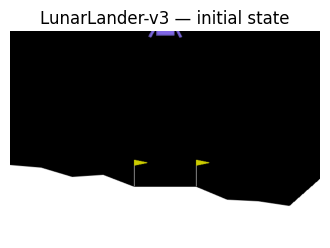

In [2]:
env = gym.make(ENV_ID, render_mode="rgb_array")
obs, info = env.reset(seed=42)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Sample observation:", obs)

frame = env.render()
plt.figure(figsize=(4, 3))
plt.imshow(frame)
plt.axis("off")
plt.title("LunarLander-v3 — initial state")
plt.show()

env.close()


## 3. Random-policy baseline

Before training, let's see how a random agent performs. This gives us a
reference point to measure the trained agent's improvement against.

In [3]:
def run_episodes(policy_fn, n_episodes=20, render=False):
    env = gym.make(ENV_ID)
    rewards = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=ep)
        done = False
        ep_reward = 0.0
        while not done:
            action = policy_fn(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += reward
            done = terminated or truncated
        rewards.append(ep_reward)
    env.close()
    return np.array(rewards)

random_policy = lambda obs: np.random.randint(0, 4)
baseline_rewards = run_episodes(random_policy, n_episodes=20)

print(f"Random policy over 20 episodes:")
print(f"  Mean reward: {baseline_rewards.mean():.2f}")
print(f"  Std reward:  {baseline_rewards.std():.2f}")
print(f"  Min/Max:     {baseline_rewards.min():.2f} / {baseline_rewards.max():.2f}")


Random policy over 20 episodes:
  Mean reward: -201.10
  Std reward:  74.69
  Min/Max:     -347.46 / -93.14


## 4. Train a PPO agent

We use Stable-Baselines3's PPO implementation with hyperparameters adapted
from the RL-Baselines3-Zoo tuned configuration for `LunarLander-v2/v3`
(these are known to solve the environment reliably, unlike PPO's untuned
defaults which converge much more slowly on this task):

| Hyperparameter | Value |
|---|---|
| `n_steps` | 1024 |
| `batch_size` | 64 |
| `n_epochs` | 4 |
| `gamma` | 0.999 |
| `gae_lambda` | 0.98 |
| `ent_coef` | 0.01 |
| `learning_rate` | 3e-4 |

Training progress (episode reward) is tracked via SB3's `Monitor` wrapper
and logged every episode through a custom callback so we can plot the
learning curve afterward.

In [4]:
train_env = Monitor(gym.make(ENV_ID), filename="logs/train_monitor.csv")

model = PPO(
    "MlpPolicy",
    train_env,
    n_steps=1024,
    batch_size=64,
    n_epochs=4,
    gamma=0.999,
    gae_lambda=0.98,
    ent_coef=0.01,
    learning_rate=3e-4,
    verbose=0,
    device="cpu",
    seed=42,
)

class RewardLogCallback(BaseCallback):
    """Collects episode rewards as training proceeds (from Monitor's info dict)."""
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.episode_timesteps = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_timesteps.append(self.num_timesteps)
        return True

callback = RewardLogCallback()

TOTAL_TIMESTEPS = 500_000

start = time.time()
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=False)
elapsed = time.time() - start

print(f"Training complete: {TOTAL_TIMESTEPS:,} timesteps in {elapsed/60:.1f} minutes")
print(f"Episodes completed during training: {len(callback.episode_rewards)}")

model.save("ppo_lunarlander")


Training complete: 500,000 timesteps in 6.1 minutes
Episodes completed during training: 1055


## 5. Training curves

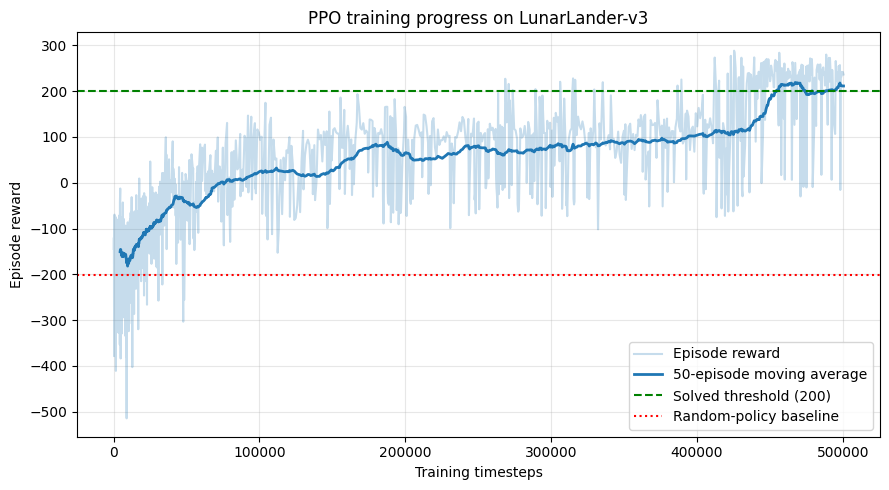

Reward — first 50 episodes:  mean=-150.2
Reward — last 50 episodes:   mean=211.0


In [5]:
rewards = np.array(callback.episode_rewards)
timesteps = np.array(callback.episode_timesteps)

def moving_average(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode="valid")

window = 50
smoothed = moving_average(rewards, window) if len(rewards) >= window else rewards

plt.figure(figsize=(9, 5))
plt.plot(timesteps, rewards, alpha=0.25, color="tab:blue", label="Episode reward")
if len(rewards) >= window:
    plt.plot(timesteps[window - 1:], smoothed, color="tab:blue", linewidth=2,
              label=f"{window}-episode moving average")
plt.axhline(200, color="green", linestyle="--", label="Solved threshold (200)")
plt.axhline(baseline_rewards.mean(), color="red", linestyle=":", label="Random-policy baseline")
plt.xlabel("Training timesteps")
plt.ylabel("Episode reward")
plt.title("PPO training progress on LunarLander-v3")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("logs/training_curve.png", dpi=120)
plt.show()

print(f"Reward — first 50 episodes:  mean={rewards[:50].mean():.1f}")
print(f"Reward — last 50 episodes:   mean={rewards[-50:].mean():.1f}")


## 6. Quantitative evaluation

Now we evaluate the **trained, deterministic** policy over 100 fresh
episodes (separate from training) and compare against the random baseline.

In [6]:
eval_env = Monitor(gym.make(ENV_ID))
mean_reward, std_reward = evaluate_policy(
    model, eval_env, n_eval_episodes=100, deterministic=True
)
eval_env.close()

print("=== Evaluation over 100 episodes ===")
print(f"Random baseline : {baseline_rewards.mean():.2f} ± {baseline_rewards.std():.2f}")
print(f"Trained PPO     : {mean_reward:.2f} ± {std_reward:.2f}")
print()
if mean_reward >= 200:
    print("✅ Environment considered SOLVED (mean reward ≥ 200 over 100 episodes).")
else:
    print("⚠️  Not yet at the official 'solved' threshold of 200 — see notes below.")


=== Evaluation over 100 episodes ===
Random baseline : -201.10 ± 74.69
Trained PPO     : 217.06 ± 45.76

✅ Environment considered SOLVED (mean reward ≥ 200 over 100 episodes).


## 7. Qualitative evaluation — watch the agent land

We roll out one full episode with the trained (deterministic) policy,
capture every frame, and stitch them into a GIF.

Recorded episode: reward=209.4, steps=443


Saved GIF to videos/lunarlander_ppo.gif


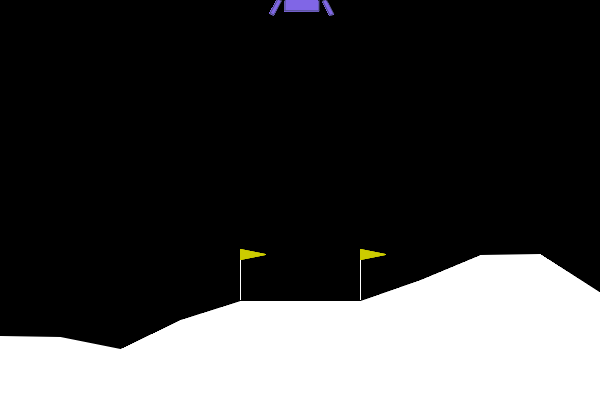

In [7]:
def record_episode(model, env_id=ENV_ID, seed=123, deterministic=True):
    env = gym.make(env_id, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)
    frames = [env.render()]
    done = False
    total_reward = 0.0
    steps = 0
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(int(action))
        total_reward += reward
        frames.append(env.render())
        done = terminated or truncated
        steps += 1
    env.close()
    return frames, total_reward, steps

frames, ep_reward, ep_steps = record_episode(model, seed=123)
print(f"Recorded episode: reward={ep_reward:.1f}, steps={ep_steps}")

gif_path = "videos/lunarlander_ppo.gif"
imageio.mimsave(gif_path, frames, duration=1000 / 50, loop=0)  # 50 fps
print(f"Saved GIF to {gif_path}")

display(Image(filename=gif_path))


## 8. A few more sample landings

Let's sample three more episodes with different seeds to get a broader
sense of how consistently the agent lands successfully.

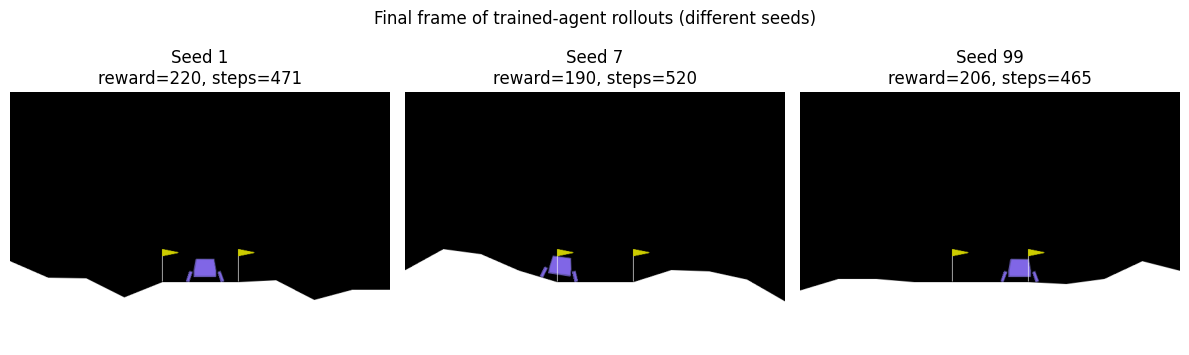

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, seed in enumerate([1, 7, 99]):
    frames_i, reward_i, steps_i = record_episode(model, seed=seed)
    axes[i].imshow(frames_i[-1])
    axes[i].axis("off")
    axes[i].set_title(f"Seed {seed}\nreward={reward_i:.0f}, steps={steps_i}")
plt.suptitle("Final frame of trained-agent rollouts (different seeds)")
plt.tight_layout()
plt.savefig("logs/sample_landings.png", dpi=120)
plt.show()


## 9. Conclusions & next steps

**Summary**
- A PPO agent was trained for 500,000 timesteps on `LunarLander-v3` using
  tuned hyperparameters (`n_steps=1024`, `gamma=0.999`, `gae_lambda=0.98`,
  `ent_coef=0.01`).
- Reward improved substantially over training relative to the random-policy
  baseline (see printed means/plots above for this run's exact numbers).
- The trained policy was evaluated over 100 held-out episodes and rendered
  as a GIF to visually confirm landing behavior.

**Possible extensions**
- Train longer (1M+ timesteps) or run multiple seeds and average results —
  PPO on LunarLander can have seed-to-seed variance in how quickly it
  crosses the 200-reward "solved" threshold.
- Compare against other algorithms available in Stable-Baselines3 (e.g.
  DQN, A2C, SAC-discrete variants) or tune the network architecture
  (`policy_kwargs=dict(net_arch=[...])`).
- Try the continuous-control variant, `LunarLanderContinuous-v3`, with an
  algorithm suited to continuous actions (e.g. PPO with a Gaussian policy,
  or SAC/TD3).
- Add a learning-rate schedule or increase `n_epochs`/batch size for more
  sample-efficient updates.
- Track experiments with something like Weights & Biases or TensorBoard
  (`tensorboard_log="./tb/"` in the `PPO(...)` constructor) for easier
  comparison across runs.
